# TP 3.2 : Modélisation, Modèle linéaire et ANOVA

## 1. Régression linéaire simple

Pour ce premier exercice, nous manipulerons le jeu de données `cars`.

In [1]:
help(cars)

cars                 package:datasets                  R Documentation

_S_p_e_e_d _a_n_d _S_t_o_p_p_i_n_g _D_i_s_t_a_n_c_e_s _o_f _C_a_r_s

_D_e_s_c_r_i_p_t_i_o_n:

     The data give the speed of cars and the distances taken to stop.
     Note that the data were recorded in the 1920s.

_U_s_a_g_e:

     cars
     
_F_o_r_m_a_t:

     A data frame with 50 observations on 2 variables.

       [,1]  speed  numeric  Speed (mph)            
       [,2]  dist   numeric  Stopping distance (ft) 
      
_S_o_u_r_c_e:

     Ezekiel, M. (1930) _Methods of Correlation Analysis_.  Wiley.

_R_e_f_e_r_e_n_c_e_s:

     McNeil, D. R. (1977) _Interactive Data Analysis_.  Wiley.

_E_x_a_m_p_l_e_s:

     require(stats); require(graphics)
     plot(cars, xlab = "Speed (mph)", ylab = "Stopping distance (ft)",
          las = 1)
     lines(lowess(cars$speed, cars$dist, f = 2/3, iter = 3), col = "red")
     title(main = "cars data"

In [4]:
cars 

speed,dist
<dbl>,<dbl>
4,2
4,10
7,4
7,22
8,16
9,10
10,18
10,26
10,34


<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>À partir des formules rappelées en cours, calculer l'équation de la droite de régression de <code>cars&dollar;dist</code> en fonction de <code>cars&dollar;speed</code>.</li>
        <li>Retrouver ce résultat directement grâce à la fonction <code>lm()</code>.</li>
        <li>Calculer la part de variance expliquée par le modèle en fonction du rapport de la variance des résidus sur la variance initiale. Cette quantité s'appelle <i>coefficient de détermination linéaire de Pearson</i> ou plus simplement $R^2$.</li>
        <li>Représenter graphiquement le nuage de points des données traversé par la droite de régression.<br>
            <center><img src="img/regression_simple.png"></center>
        </li>
    </ol>
</div>

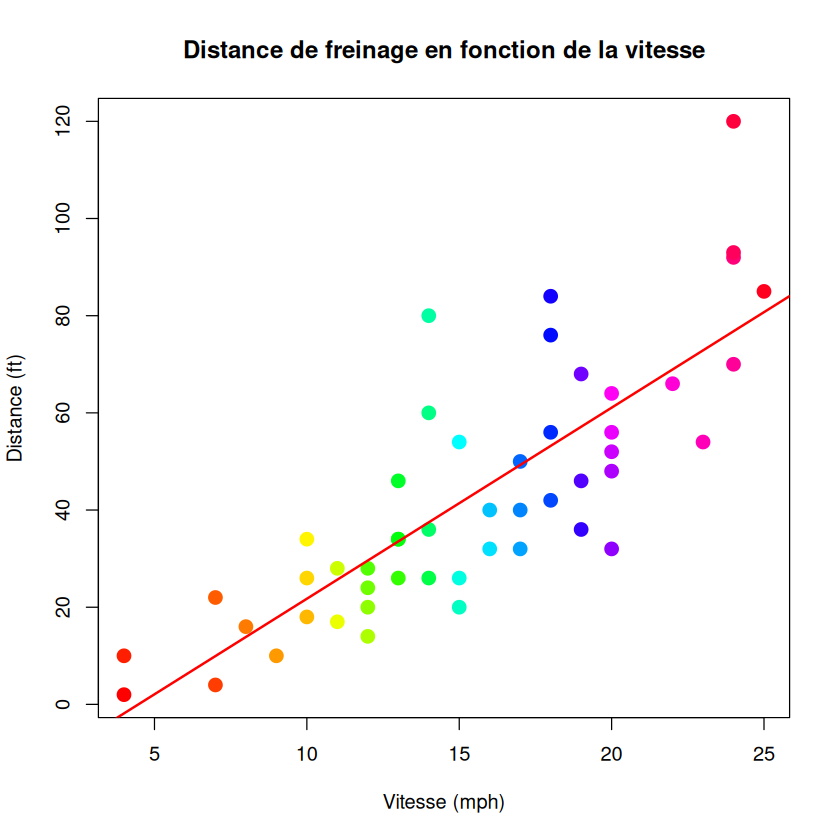

In [13]:
# À FAIRE

#2
par(bg = "white")

# Nombre de points
n <- nrow(cars)

# Palette arc-en-ciel
couleurs <- rainbow(n)

# Nuage de points avec couleurs différentes
plot(cars$speed, cars$dist,
     main = "Distance de freinage en fonction de la vitesse",
     xlab = "Vitesse (mph)",
     ylab = "Distance (ft)",
     pch = 19,
     cex = 1.5,          # forme des points
     col = couleurs)    # couleur arc-en-ciel


modele <- lm(dist ~ speed, data = cars)

abline(modele, col = "red", lwd = 2)



## 2. Régression linéaire multiple

Le cadre général du modèle de régression linéaire peut être donné par un vecteur $y \in \mathbb{R}^n$ contenant les $n$ observations de la *variable à expliquer* et par une matrice $X \in \mathbb{R}^{n \times p}$ contenant les $n$ observations des $p$ *variables explicatives*. Parmi les variables explicatives, une colonne de 1 est souvent ajoutée pour traiter l'ordonnée à l'origine comme les autres variables et unifier les notations. La relation recherchée se formule à l'aide du *vecteur des coefficients* $\theta \in \mathbb{R}^p$,
\begin{equation*}
y = X\theta + \varepsilon
\end{equation*}
où $\varepsilon \in \mathbb{R}^n$ est le vecteur des résidus. Des calculs similaires à ceux vus en cours pour le critère des moindres carrés donnent la formulation matricielle de l'estimateur $\hat{\theta}$ lorsque la matrice $X^\top X$ est inversible,
\begin{equation*}
\hat{\theta} = (X^\top X)^{-1} X^\top y.
\end{equation*}

Nous considérons maintenant le jeu de données `swiss`.

In [ ]:
help(swiss)

In [2]:
swiss

,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
Courtelary,80.2,17.0,15,12,9.96,22.2
Delemont,83.1,45.1,6,9,84.84,22.2
Franches-Mnt,92.5,39.7,5,5,93.40,20.2
Moutier,85.8,36.5,12,7,33.77,20.3
Neuveville,76.9,43.5,17,15,5.16,20.6
Porrentruy,76.1,35.3,9,7,90.57,26.6
Broye,83.8,70.2,16,7,92.85,23.6
Glane,92.4,67.8,14,8,97.16,24.9
Gruyere,82.4,53.3,12,7,97.67,21.0


<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Effectuer la régression linéaire multiple modélisant la fertilité en fonction des autres variables à l'aide de la fonction <code>lm()</code>.</li>
        <li>Recalculer les coefficients de la régression par la formule matricielle donnée ci-dessus.</li>
        <li>Utiliser la fonction <code>step()</code> pour réduire la dimension du modèle en retirant les variables négligeables.</li>
    </ol>
</div>

In [4]:
# 1.

modele_multiple <- lm(swiss$Fertility ~ swiss$Agriculture + swiss$Examination +swiss$Education +swiss$Catholic + swiss$Infant.Mortality, data = swiss)

summary(modele_multiple)


Call:
lm(formula = swiss$Fertility ~ swiss$Agriculture + swiss$Examination + 
    swiss$Education + swiss$Catholic + swiss$Infant.Mortality, 
    data = swiss)

Residuals:
     Min       1Q   Median       3Q      Max 
-15.2743  -5.2617   0.5032   4.1198  15.3213 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            66.91518   10.70604   6.250 1.91e-07 ***
swiss$Agriculture      -0.17211    0.07030  -2.448  0.01873 *  
swiss$Examination      -0.25801    0.25388  -1.016  0.31546    
swiss$Education        -0.87094    0.18303  -4.758 2.43e-05 ***
swiss$Catholic          0.10412    0.03526   2.953  0.00519 ** 
swiss$Infant.Mortality  1.07705    0.38172   2.822  0.00734 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.165 on 41 degrees of freedom
Multiple R-squared:  0.7067,	Adjusted R-squared:  0.671 
F-statistic: 19.76 on 5 and 41 DF,  p-value: 5.594e-10


\begin{equation*}
\hat{\theta} = (X^\top X)^{-1} X^\top y.
\end{equation*}

In [18]:
#2.

X <- as.matrix(swiss[, 2:ncol(swiss)])
theta <- solve(t(X) %*% X) %*% t(X) %*% swiss[,1]

theta

Agriculture,0.1110005
Examination,0.4440591
Education,-0.7067362
Catholic,0.1170662
Infant.Mortality,2.9836617


In [19]:
#3

modele_final <- step(modele_multiple, 
                     direction = "both", 
                     trace = TRUE)

modele_final

Start:  AIC=190.69
swiss$Fertility ~ swiss$Agriculture + swiss$Examination + swiss$Education + 
    swiss$Catholic + swiss$Infant.Mortality

                         Df Sum of Sq    RSS    AIC
- swiss$Examination       1     53.03 2158.1 189.86
<none>                                2105.0 190.69
- swiss$Agriculture       1    307.72 2412.8 195.10
- swiss$Infant.Mortality  1    408.75 2513.8 197.03
- swiss$Catholic          1    447.71 2552.8 197.75
- swiss$Education         1   1162.56 3267.6 209.36

Step:  AIC=189.86
swiss$Fertility ~ swiss$Agriculture + swiss$Education + swiss$Catholic + 
    swiss$Infant.Mortality

                         Df Sum of Sq    RSS    AIC
<none>                                2158.1 189.86
+ swiss$Examination       1     53.03 2105.0 190.69
- swiss$Agriculture       1    264.18 2422.2 193.29
- swiss$Infant.Mortality  1    409.81 2567.9 196.03
- swiss$Catholic          1    956.57 3114.6 205.10
- swiss$Education         1   2249.97 4408.0 221.43



Call:
lm(formula = swiss$Fertility ~ swiss$Agriculture + swiss$Education + 
    swiss$Catholic + swiss$Infant.Mortality, data = swiss)

Coefficients:
           (Intercept)       swiss$Agriculture         swiss$Education  
               62.1013                 -0.1546                 -0.9803  
        swiss$Catholic  swiss$Infant.Mortality  
                0.1247                  1.0784  


## 3. Analyse de variance

Dans cette dernière partie, nous utiliserons le jeu de données `iris`.

In [21]:
#help(iris)

iris

Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
<dbl>,<dbl>,<dbl>,<dbl>,<fct>
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa
4.6,3.4,1.4,0.3,setosa
5.0,3.4,1.5,0.2,setosa
4.4,2.9,1.4,0.2,setosa


<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Représenter les boxplots de chacune des 4 variables en fonction des modalités de la variable <code>Species</code>.<br>
            <center><img src="img/iris.png"></center>
        </li>
        <li>On souhaite appliquer une ANOVA sur chacun des variable quantitative de ce jeux de donnée. Que cherche-t-on à tester ? </li>
        <li>Le bon fonctionnement de l'ANOVA repose sur des hypothèses, quelles sont t'elle ? Mettez en place un tester pour vérifier si elles semble raisonnable sur ce jeux de données. </li>
        <li>Pour chaque variable quantitative du jeu de données <code>iris</code>, utiliser la fonction <code>aov()</code> puis <code>print()</code> et <code>summary()</code> sur le résultat pour appliquer l'ANOVA.</li>
    </ol>
</div>

[1] setosa     versicolor virginica 
Levels: setosa versicolor virginica

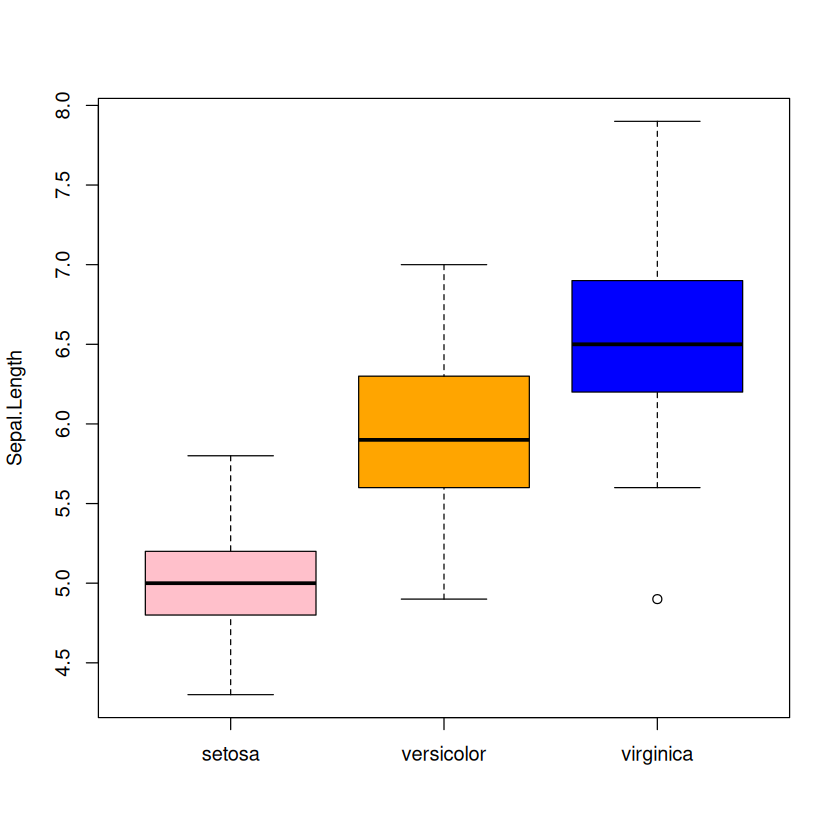

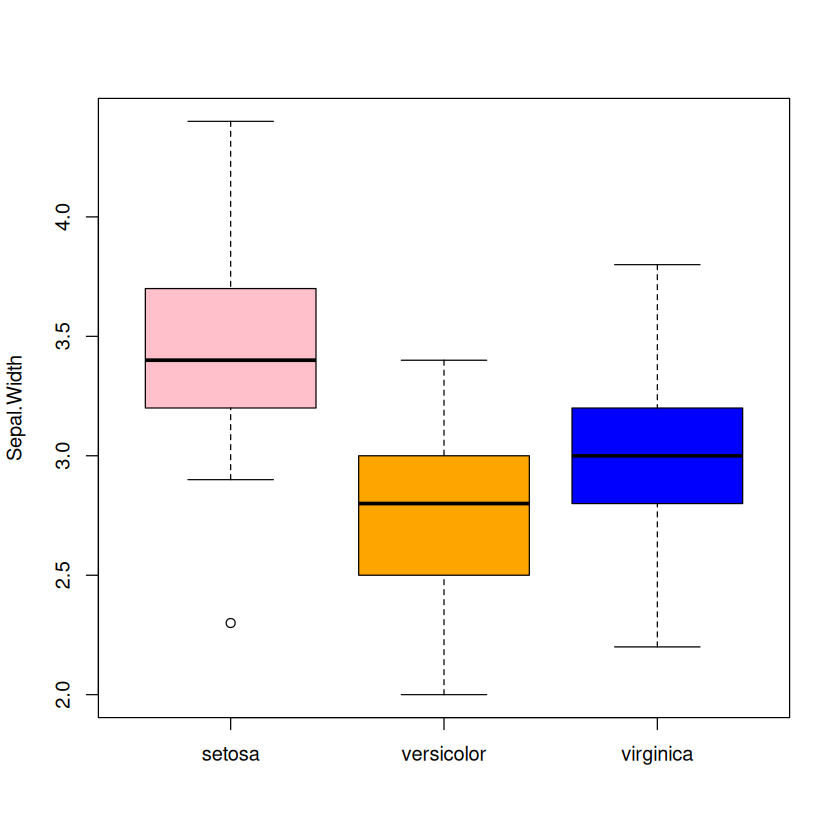

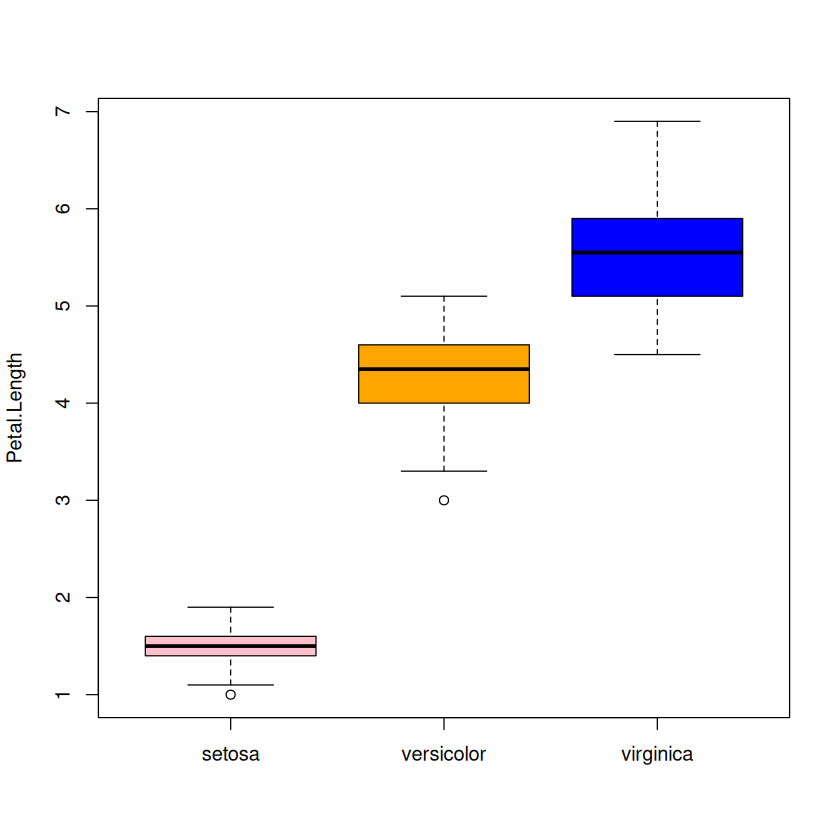

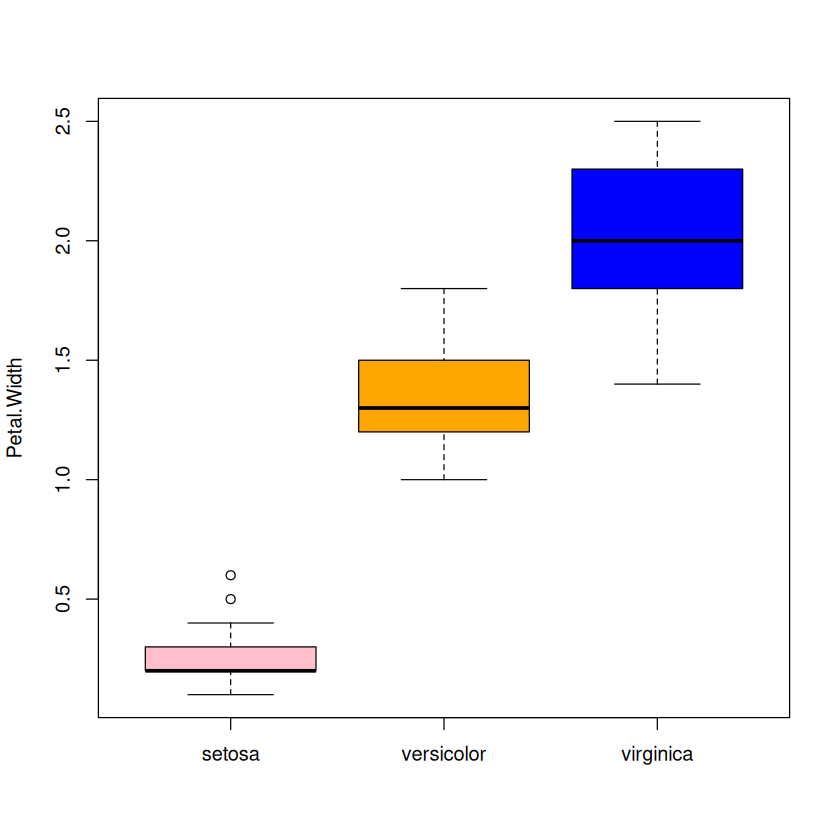

In [37]:
# À FAIRE

#1.

species <- unique(iris$Species)
species

par(bg = "white")
for(j in 1:(ncol(iris)-1)){
    boxplot(iris[iris$Species==species[1], j], iris[iris$Species==species[2], j], iris[iris$Species==species[3], j],
    names = species, ylab = colnames(iris)[j], col = c('pink', 'orange', 'blue'))
}
    




<li>On souhaite appliquer une ANOVA sur chacun des variable quantitative de ce jeux de donnée. Que cherche-t-on à tester ? </li>
        <li>Le bon fonctionnement de l'ANOVA repose sur des hypothèses, quelles sont t'elle ? Mettez en place un tester pour vérifier si elles semble raisonnable sur ce jeux de données. </li>
        <li>Pour chaque variable quantitative du jeu de données <code>iris</code>, utiliser la fonction <code>aov()</code> puis <code>print()</code> et <code>summary()</code> sur le résultat pour appliquer l'ANOVA.</li>
    </ol>
</div>

#2 on cherche à tester si pour chaque variable, les moyennes sont égales pour les trois espèces 

#3 hypothèses 

    1. Indépendance des observations 

    Chaque observation doit être indépendante des autres. 

    2. Normalité des résidus : test de Shapiro-Wilk

    Les valeurs dans chaque groupe doivent suivre une distribution normale. 

    3. Homogénéité des variances : Barlett ou Levene

    Les variances dans chaque groupe doivent être à peu près égales. 

 

In [39]:
#hyp 2 : vérifier la normalité des résidus 

shapiro.test(iris$Sepal.Length[iris$Species == "setosa"])
shapiro.test(iris$Sepal.Length[iris$Species == "versicolor"])
shapiro.test(iris$Sepal.Length[iris$Species == "virginica"])

#hyp 3 
bartlett.test(Sepal.Length ~ Species, data = iris)
# ou avec car::leveneTest
# library(car)
# leveneTest(Sepal.Length ~ Species, data = iris)





	Shapiro-Wilk normality test

data:  iris$Sepal.Length[iris$Species == "setosa"]
W = 0.9777, p-value = 0.4595



	Shapiro-Wilk normality test

data:  iris$Sepal.Length[iris$Species == "versicolor"]
W = 0.97784, p-value = 0.4647



	Shapiro-Wilk normality test

data:  iris$Sepal.Length[iris$Species == "virginica"]
W = 0.97118, p-value = 0.2583



	Bartlett test of homogeneity of variances

data:  Sepal.Length by Species
Bartlett's K-squared = 16.006, df = 2, p-value = 0.0003345


Les résidus peuvent être considérés comme approximativement normaux pour chaque espèce.

En revanche on rejette l'hyp d'himogénéité pour sepal.length

In [40]:
# Liste des variables quantitatives
vars <- c("Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width")

for (v in vars) {
  cat("\nANOVA pour :", v, "\n")
  
  # Formule dynamique
  formule <- as.formula(paste(v, "~ Species"))
  
  # Ajuster le modèle
  res <- aov(formule, data = iris)
  
  # Affichage
  print(res)        # résumé simple
  print(summary(res))  # tableau ANOVA complet
}



ANOVA pour : Sepal.Length 
Call:
   aov(formula = formule, data = iris)

Terms:
                 Species Residuals
Sum of Squares  63.21213  38.95620
Deg. of Freedom        2       147

Residual standard error: 0.5147894
Estimated effects may be unbalanced
             Df Sum Sq Mean Sq F value Pr(>F)    
Species       2  63.21  31.606   119.3 <2e-16 ***
Residuals   147  38.96   0.265                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

ANOVA pour : Sepal.Width 
Call:
   aov(formula = formule, data = iris)

Terms:
                 Species Residuals
Sum of Squares  11.34493  16.96200
Deg. of Freedom        2       147

Residual standard error: 0.3396877
Estimated effects may be unbalanced
             Df Sum Sq Mean Sq F value Pr(>F)    
Species       2  11.35   5.672   49.16 <2e-16 ***
Residuals   147  16.96   0.115                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

ANOVA pour : Petal.Length 
Call:
   aov(formula = 

Pour toutes les variables quantitatives du iris, les ANOVA montrent p-value < 0.05 → toutes les moyennes diffèrent significativement entre espèces.